**Generate Realistice Data**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
#Reproducibility
np.random.seed(42)
#----------------
# User Table 
#----------------
n_users=1000
user_ids=np.arange(1,n_users+1)
users=pd.DataFrame({
    "user_id":user_ids,
    "Signup_date":pd.to_datetime("2023-01-01")+
    pd.to_timedelta(np.random.randint(0,365,n_users),unit="D"),
    "Country":np.random.choice(["India","US","UK","Africa"],n_users),
    "Device":np.random.choice(["Mobile","Laptop","Mouse","Keyboard","TV"],n_users)

})

#-----------------
#Events
#---------------

events_per_user=np.random.randint(5,20,size=n_users)
n_events_total = events_per_user.sum()#each user has multiple events
events=pd.DataFrame({
    "user_id":np.repeat(user_ids,events_per_user),
    "event_type":np.random.choice(["login","click","view","purchase"],n_events_total),
    "event_time":pd.to_datetime("2023-01-01")+
                 pd.to_timedelta(np.random.randint(0,365,n_events_total),unit="D")

        #Shuffle events(important for realistic dataset)
        
})
events=events.sample(frac=1,random_state=42).reset_index(drop=True)
        #---------------------
        #Subscription Table
        #---------------------
subs=pd.DataFrame({
    "user_id":user_ids,
    "plan":np.random.choice(["Basic","Pro"],n_users,p=[0.7,0.3])
})
        #-------------------
        # Quick Validation
        #-------------------


In [2]:
events.head()

,user_id,event_type,event_time
0,581,purchase,2023-03-30
1,701,click,2023-02-24
2,658,click,2023-10-17
3,27,view,2023-10-18
4,318,login,2023-03-08


In [3]:
events.tail()

,user_id,event_type,event_time
11933,946,login,2023-05-10
11934,435,login,2023-05-30
11935,451,view,2023-11-09
11936,70,click,2023-11-10
11937,609,login,2023-03-23


In [4]:
events["user_id"].value_counts().head()

user_id
145    19
46     19
126    19
200    19
642    19
Name: count, dtype: int64

In [5]:
print(events["user_id"].nunique())# should be 1000

1000


In [6]:
subs

,user_id,plan
0,1,Basic
1,2,Basic
2,3,Basic
3,4,Basic
4,5,Basic
...,...,...
995,996,Basic
996,997,Basic
997,998,Basic
998,999,Pro


In [7]:
users.head()

,user_id,Signup_date,Country,Device
0,1,2023-04-13,UK,TV
1,2,2023-12-15,UK,Keyboard
2,3,2023-09-28,India,TV
3,4,2023-04-17,US,Mouse
4,5,2023-03-13,US,Mobile


**One row per user**:
**Aggregate Events**

In [8]:
events_agg=(
events.groupby("user_id").agg(
    total_events=("event_type","count"),
    unique_events=("event_type","nunique"),
    last_event_time=("event_time","max")
)
.reset_index()
)


In [9]:
data=(
    users
    .merge(events_agg,on="user_id",how="left")
    .merge(subs,on="user_id",how="left")
)

**Checking the columns of users and events_agg**

In [10]:
print(users.columns)
print(events_agg.columns)

Index(['user_id', 'Signup_date', 'Country', 'Device'], dtype='object')
Index(['user_id', 'total_events', 'unique_events', 'last_event_time'], dtype='object')


In [11]:
data.head()

,user_id,Signup_date,Country,Device,total_events,unique_events,last_event_time,plan
0,1,2023-04-13,UK,TV,13,4,2023-12-10,Basic
1,2,2023-12-15,UK,Keyboard,19,4,2023-12-07,Basic
2,3,2023-09-28,India,TV,8,3,2023-12-04,Basic
3,4,2023-04-17,US,Mouse,12,4,2023-11-28,Basic
4,5,2023-03-13,US,Mobile,13,4,2023-11-20,Basic


**Getting information about our dataset like total no of rows,total no of columns,datatype of each column 
and memory requirement**

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   user_id          1000 non-null   int64         
 1   Signup_date      1000 non-null   datetime64[ns]
 2   Country          1000 non-null   object        
 3   Device           1000 non-null   object        
 4   total_events     1000 non-null   int64         
 5   unique_events    1000 non-null   int64         
 6   last_event_time  1000 non-null   datetime64[ns]
 7   plan             1000 non-null   object        
dtypes: datetime64[ns](2), int64(3), object(3)
memory usage: 62.6+ KB


In [13]:
data.describe()

,user_id,Signup_date,total_events,unique_events,last_event_time
count,1000.000000,1000,1000.000000,1000.00000,1000
mean,500.500000,2023-07-01 13:22:04.800000,11.938000,3.76700,2023-11-28 20:25:26.400000
min,1.000000,2023-01-01 00:00:00,5.000000,2.00000,2023-05-12 00:00:00
25%,250.750000,2023-04-08 00:00:00,8.000000,4.00000,2023-11-16 00:00:00
50%,500.500000,2023-07-01 12:00:00,12.000000,4.00000,2023-12-09 00:00:00
75%,750.250000,2023-09-27 06:00:00,16.000000,4.00000,2023-12-22 00:00:00
max,1000.000000,2023-12-31 00:00:00,19.000000,4.00000,2023-12-31 00:00:00
std,288.819436,NaN,4.333236,0.45046,NaN


**Checking for null values in the data**

In [14]:
data.isna().sum()

user_id            0
Signup_date        0
Country            0
Device             0
total_events       0
unique_events      0
last_event_time    0
plan               0
dtype: int64

**Checking if there any duplicated values**

In [15]:
data.duplicated().sum()

np.int64(0)

**Checking the data details which are greater than 10 total_events**

In [16]:
data[data['total_events']>15].sort_values(by='total_events')

,user_id,Signup_date,Country,Device,total_events,unique_events,last_event_time,plan
76,77,2023-09-28,UK,TV,16,4,2023-12-12,Basic
96,97,2023-11-23,Africa,Keyboard,16,4,2023-10-04,Basic
123,124,2023-02-04,India,Mouse,16,3,2023-12-09,Basic
128,129,2023-01-05,US,Keyboard,16,4,2023-12-23,Basic
889,890,2023-12-31,India,Laptop,16,4,2023-12-24,Basic
...,...,...,...,...,...,...,...,...
144,145,2023-08-10,Africa,Keyboard,19,4,2023-12-05,Pro
139,140,2023-12-18,India,Mobile,19,4,2023-12-23,Pro
133,134,2023-07-26,India,Mouse,19,4,2023-12-28,Pro
125,126,2023-04-11,UK,Mobile,19,4,2023-12-24,Basic


**Count each device type in each country**

In [17]:
country_wise_device=(
    data.groupby(["Country","Device"])
        .size()
        #.sort_values(ascending=False)
        .reset_index(name="count")
        
)
country_wise_device

,Country,Device,count
0,Africa,Keyboard,45
1,Africa,Laptop,51
2,Africa,Mobile,44
3,Africa,Mouse,49
4,Africa,TV,38
5,India,Keyboard,50
6,India,Laptop,63
7,India,Mobile,55
8,India,Mouse,44
9,India,TV,54


**Download the generated data for furthuer use in sql and excel**

In [18]:
data.to_csv("saas_data.csv",index=False)

**To check the total sign up count by country wise**

In [19]:
data.columns

Index(['user_id', 'Signup_date', 'Country', 'Device', 'total_events',
       'unique_events', 'last_event_time', 'plan'],
      dtype='object')

In [20]:
country_count=(
    data.groupby("Country")["Signup_date"]
    .count()
    .sort_values(ascending=False)
    .reset_index(name="count")
)
country_count

,Country,count
0,India,266
1,UK,256
2,US,251
3,Africa,227


In [21]:
data.columns

Index(['user_id', 'Signup_date', 'Country', 'Device', 'total_events',
       'unique_events', 'last_event_time', 'plan'],
      dtype='object')

In [22]:
import matplotlib.pyplot as plt

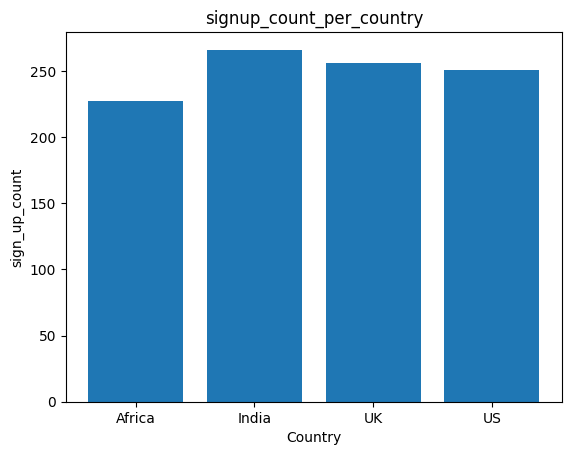

In [23]:
country_count=data.groupby("Country")["user_id"].count()
plt.bar(country_count.index,country_count.values)
plt.title("signup_count_per_country")
plt.ylabel("sign_up_count")
plt.xlabel("Country")
plt.show()


**To show sign_up mode(Baisc/Pro) count by country wise**

In [24]:
data.groupby(['Country','plan']).count().sort_index()

user_id  Signup_date  Device  total_events  unique_events  \
Country plan                                                               
Africa  Basic      153          153     153           153            153   
        Pro         74           74      74            74             74   
India   Basic      168          168     168           168            168   
        Pro         98           98      98            98             98   
UK      Basic      187          187     187           187            187   
        Pro         69           69      69            69             69   
US      Basic      179          179     179           179            179   
        Pro         72           72      72            72             72   

               last_event_time  
Country plan                    
Africa  Basic              153  
        Pro                 74  
India   Basic              168  
        Pro                 98  
UK      Basic              187  
        Pro                 69  
US      Basic              179  
        Pro                 72

<Axes: xlabel='Country', ylabel='count'>

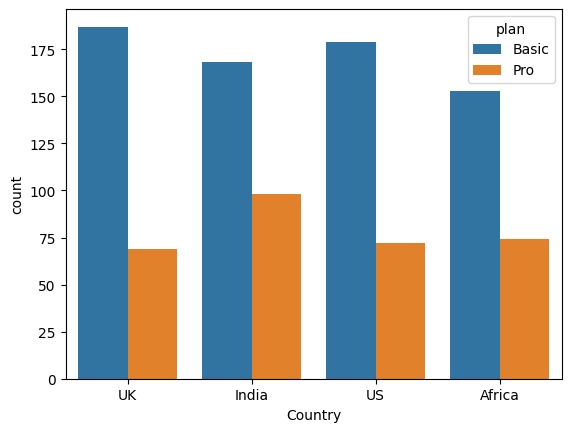

In [25]:
sns.countplot(x=data['Country'],hue=data['plan'])

**Checking total events by each country**

In [26]:
data.groupby(['Country'])['total_events'].sum()

Country
Africa    2684
India     3142
UK        3035
US        3077
Name: total_events, dtype: int64

**To show monthly signup trend analysis**

In [27]:
data['year_month']=data['Signup_date'].dt.to_period('M')

In [28]:
data.columns

Index(['user_id', 'Signup_date', 'Country', 'Device', 'total_events',
       'unique_events', 'last_event_time', 'plan', 'year_month'],
      dtype='object')

In [35]:
monthly_signup_trend=(
    data.groupby('year_month')['Signup_date']
.count().reset_index(name='total_count')
.sort_index()
#.sort_values(by='total_count',ascending=False)
)
monthly_signup_trend

,year_month,total_count
0,2023-01,78
1,2023-02,90
2,2023-03,60
3,2023-04,91
4,2023-05,96
5,2023-06,84
6,2023-07,75
7,2023-08,104
8,2023-09,82
9,2023-10,79


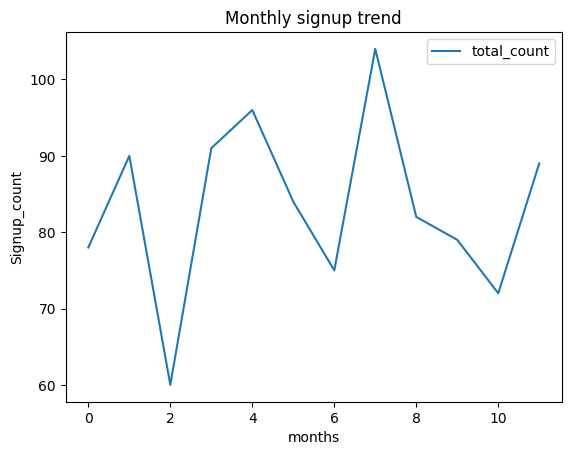

In [36]:
monthly_signup_trend.plot()
plt.xlabel("months")
plt.ylabel("Signup_count")
plt.title("Monthly signup trend")
plt.show()